In [1]:
import os
import glob
import torch
import xml.etree.ElementTree as ET
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms as transforms
# from google.colab.patches import cv2_imshow
import cv2

# Data Prep

In [3]:
!pip install --quiet kaggle
!kaggle datasets download -d andrewmvd/dog-and-cat-detection --unzip -p ./cat_dog_dataset

print("Dataset downloaded and extracted into the './cat_dog_dataset' folder!")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/dog-and-cat-detection
License(s): CC-BY-SA-4.0
100%|██████████████████████████████████████| 1.03G/1.03G [00:49<00:00, 22.5MB/s]

Dataset downloaded and extracted into the './cat_dog_dataset' folder!


In [2]:
batch_size = 8
num_epochs = 200
learning_rate = 0.001
early_stop_tolerance = 10
GRID_SIZE = 7
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

# from google.colab import drive
# drive.mount('/content/drive')

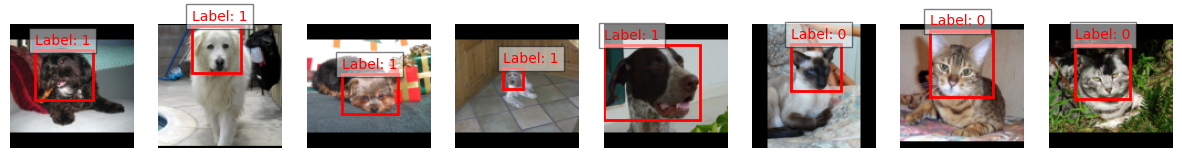

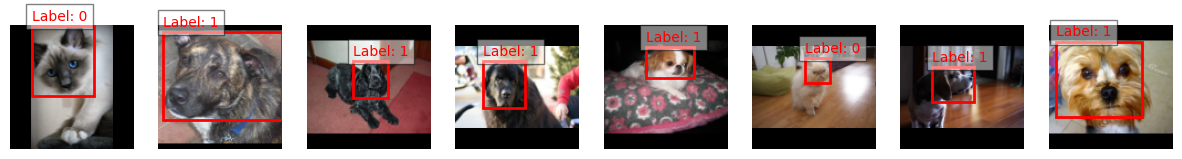

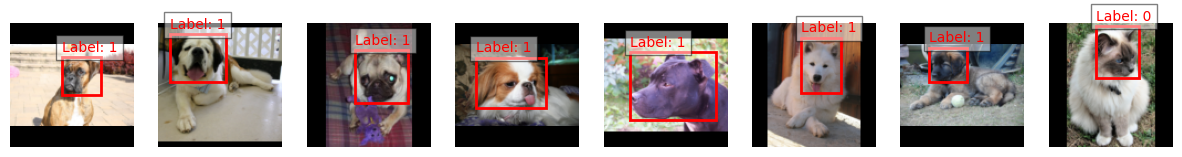

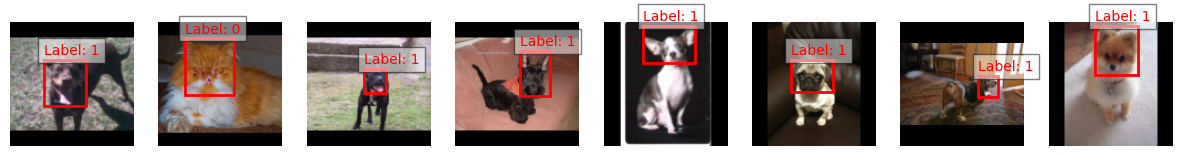

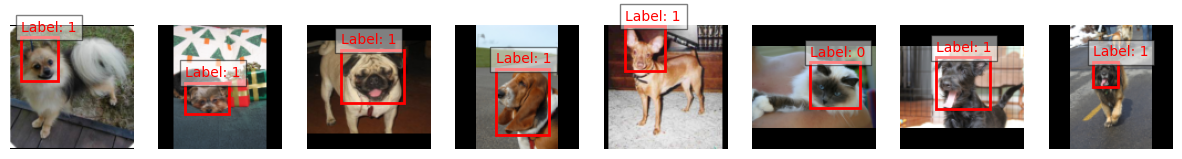

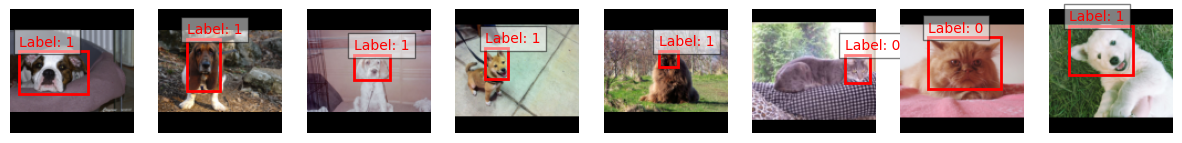

In [3]:
INPUT_IMG_SZ = 112
IMG_DIR = "./cat_dog_dataset/images"
ANNOTATION_DIR = './cat_dog_dataset/annotations'


class CatDogDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        self.img_files = sorted(glob.glob(os.path.join(img_dir, "*.png")))
        self.ann_files = sorted(glob.glob(os.path.join(ann_dir, "*.xml")))

        # Exclude the image that has 2 cats:
        self.img_files = [f for f in self.img_files if os.path.basename(f) not in ["Cats_Test736.png"]]
        self.ann_files = [f for f in self.ann_files if os.path.basename(f).replace(".xml", ".png") not in ["Cats_Test736.png"]]
        self.label_map = {"cat": 0, "dog": 1}  # Label mapping

    def parse_annotation(self, ann_path):
        tree = ET.parse(ann_path)
        root = tree.getroot()
        width = int(root.find("size/width").text)
        height = int(root.find("size/height").text)
        file_name = root.find("filename").text
        objects = []

        for obj in root.findall("object"):
            name = obj.find("name").text
            xmin = int(obj.find("bndbox/xmin").text)
            ymin = int(obj.find("bndbox/ymin").text)
            xmax = int(obj.find("bndbox/xmax").text)
            ymax = int(obj.find("bndbox/ymax").text)

            label = self.label_map.get(name, -1)  # Default to -1 if unknown label
            objects.append({"label": label, "bbox": [xmin, ymin, xmax, ymax]})

        return width, height, objects, file_name

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        ann_path = self.ann_files[idx]

        image = Image.open(img_path).convert("RGB")
        width, height, objects, file_name = self.parse_annotation(ann_path)

        # ----- RESIZING ------
        # 1. We fit the larger dimension to 112, reize the image accordingly with a single scaler
        # 2. Add padding to the shorter dimension so you get to 112x112
        # 3. Update bbox coordinates accordingly.

        # Initial resizing (1.)
        scaler = INPUT_IMG_SZ / max(width, height)
        height_scaled = int(height * scaler)
        width_scaled = int(width * scaler)

        resizer = T.Resize((height_scaled, width_scaled))
        image = resizer(image)

        # Add padding (2.)
        # Calculate padding amounts at each side
        vertical_pad_amount = (INPUT_IMG_SZ - height_scaled) #// 2
        horizontal_pad_amount = (INPUT_IMG_SZ - width_scaled) #// 2

        padding = (horizontal_pad_amount // 2, vertical_pad_amount // 2, horizontal_pad_amount - (horizontal_pad_amount // 2), vertical_pad_amount - (vertical_pad_amount // 2))
        padder = T.Pad(padding)
        image = padder(image)

        scaler_x = width / INPUT_IMG_SZ
        scaler_y = height / INPUT_IMG_SZ

        bboxes = []
        for obj in objects:
            xmin = (obj['bbox'][0] * scaler) + padding[0]
            ymin = (obj['bbox'][1] * scaler) + padding[1]
            xmax = (obj['bbox'][2] * scaler) + padding[0]
            ymax = (obj['bbox'][3] * scaler) + padding[1]
            bboxes.append([xmin, ymin, xmax, ymax])

        bboxes = torch.tensor(bboxes, dtype=torch.float32)
        labels = torch.tensor([obj["label"] for obj in objects], dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        #print(image.size())

        return image, bboxes, labels, file_name


# Define transformations
transform = T.Compose([
    T.ToTensor(),
    #transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

# Initialize dataset and dataloader
dataset = CatDogDataset(img_dir=IMG_DIR, ann_dir=ANNOTATION_DIR, transform=transform)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


# Function to visualize a batch
def visualize_batch(dataloader):
    #images, bboxes, labels = next(iter(dataloader))
    for batch_idx, (images, bboxes, labels, _) in enumerate(dataloader):
      fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

      if len(images) == 1:
          axes = [axes]

      for i, (img, bbox, label) in enumerate(zip(images, bboxes, labels)):
          img = img.permute(1, 2, 0).numpy()
          axes[i].imshow(img)

          for box, lbl in zip(bbox, label):
              xmin, ymin, xmax, ymax = box.tolist()
              rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                      linewidth=2, edgecolor='r', facecolor='none')
              axes[i].add_patch(rect)
              axes[i].text(xmin, ymin - 5, f'Label: {lbl.item()}', color='red', fontsize=10,
                          bbox=dict(facecolor='white', alpha=0.5))
          axes[i].axis('off')

      if batch_idx == 5:
        break

      plt.show()


# Visualize a batch
visualize_batch(dataloader)


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import torcheval.metrics.functional as metrics
from torchmetrics.classification import MulticlassAveragePrecision
import json
from sklearn.model_selection import train_test_split
import torch.optim.lr_scheduler as lr_scheduler
from torchsummary import summary

from torcheval.metrics import BinaryAccuracy
from torcheval.metrics import BinaryF1Score
from torcheval.metrics import BinaryPrecision
from torcheval.metrics import BinaryAUPRC
from torcheval.metrics.classification import BinaryRecall
from torcheval.metrics import BinaryAUPRC
from torchmetrics.detection import MeanAveragePrecision

"""torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)"""

import random

# Step 1: Set all random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False, warn_only=True)

set_seed(42)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

In [5]:
# Transform with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# load data
og_dataset = CatDogDataset(img_dir=IMG_DIR, ann_dir=ANNOTATION_DIR, transform=transform)
#dataloader = DataLoader(og_dataset, batch_size=1, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


# Stratification for a nice split of training-validation data so that all classes are represented during trainin
og_labels = [og_dataset[i][2] for i in range(len(og_dataset))]
trainval_indices, test_indices = train_test_split(
    range(len(og_dataset)),
    test_size=0.16,  # 16% test data
    stratify=og_labels,  # Preserve class distribution
    random_state=42
)

trainval_labels = [og_labels[i] for i in trainval_indices]

train_indices, val_indices = train_test_split(
    trainval_indices,
    test_size = 0.2,
    stratify = trainval_labels,
    random_state = 42
)

valid_labels = [og_dataset[i][2] for i in val_indices]
train_labels = [og_dataset[i][2] for i in train_indices]

train_dataset = torch.utils.data.Subset(og_dataset, train_indices)
val_dataset = torch.utils.data.Subset(og_dataset, val_indices)
test_dataset = torch.utils.data.Subset(og_dataset, test_indices)

print(f"og labels: {og_labels}")
print(f"trainval labels: {trainval_labels}")

print(f"og 1s: {np.array(og_labels).sum()}, og 0s: {len(og_labels) - np.array(og_labels).sum()}")
print(f"trainval 1s: {np.array(trainval_labels).sum()}, trainval 0s: {len(trainval_labels) - np.array(trainval_labels).sum()}")
print(f"train 1s: {np.array(train_labels).sum()}, trainval 0s: {len(train_labels) - np.array(train_labels).sum()}")
print(f"validation 1s: {np.array(valid_labels).sum()}, trainval 0s: {len(valid_labels) - np.array(valid_labels).sum()}")



# Divide traininf data as training-validation
# We use generator for reproducability
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
valid_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, generator=g)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True, generator=g)

print(f"Train data: {len(train_loader)}")
print(f"Valid data: {len(valid_loader)}")
print(f"Test data: {len(test_loader)}")

og labels: [tensor([0]), tensor([1]), tensor([1]), tensor([0]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([0]), tensor([1]), tensor([0]), tensor([0]), tensor([0]), tensor([1]), tensor([1]), tensor([0]), tensor([1]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([1]), tensor([0]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([1]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([0]), tensor([1]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([0]), tensor([1]), tensor([0]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([1]), tensor([1]), tensor([1]), tensor([0]), tensor([1]), tensor([1]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([0]), tensor([1]), tensor([1]), tensor([1]), tensor([1]), tensor([1]), tensor([0]), tensor([0]), 

### Data Augmentation for Class Balancing 

In [6]:
# BALANCE DATASET
import torchvision.transforms.functional as anan
import torch
from collections import Counter
from torch.utils.data import ConcatDataset

def augment_balance(dataset):
    # Count the occurrences of each label
    class_counts = Counter()
    for example in dataset:
        box = example[1]
        label = example[2]  # Extract label
        label_value = label.tolist()[0] if isinstance(label, torch.Tensor) else label
        class_counts[label_value] += 1

    # Determine the imbalance
    class_diff = max(class_counts.values()) - min(class_counts.values())

    augmented_data = []
    i, e = 0, 0
    while i < class_diff and e < len(dataset):
        img, box, label, other = dataset[e]  # Extract data (assumed to be (img, box, label))

        if label == 0:  # Apply augmentation only to the minority class
            img_transformed = anan.adjust_brightness(img, brightness_factor=1.2)
            img_transformed = anan.adjust_contrast(img_transformed, contrast_factor=1.2)
            img_transformed = anan.adjust_saturation(img_transformed, saturation_factor=1.2)
            img_transformed = anan.adjust_hue(img_transformed, hue_factor=0.1)

            # Store the augmented version
            augmented_data.append((img_transformed, box, label, other))

            i += 1  # Increment augmentation counter
        if e == len(dataset) - 1:
            e = 0
            # i = 0  # Reset augmentation counter
        e += 1  # Always increment dataset iterator

    return augmented_data

# Apply augmentation
train_dataset = torch.utils.data.Subset(og_dataset, train_indices)
train_balanced = augment_balance(train_dataset)
# Ensure that the augmented dataset contains only images from the training set
# train_balanced = torch.utils.data.Subset(train_balanced, train_indices)  # Using only train_indices

# Combine the original dataset with the augmented dataset
full_train_balanced = ConcatDataset([train_dataset] + [train_balanced])
train_loader_balanced = torch.utils.data.DataLoader(full_train_balanced, batch_size=batch_size, shuffle=True, generator=g)

# Print the sizes of the data loaders
print(f"Train data: {len(train_loader_balanced)}")

Train data: 420


In [7]:
from collections import Counter

# Initialize a counter to keep track of class counts
class_counts = Counter()

# Iterate through the dataset
for example in full_train_balanced:
    # Count the occurrences of each label
    label = example[2]  # Assuming example[2] contains the label directly, not a tensor
    label_value = label.tolist()[0] if isinstance(label, torch.Tensor) else label
    class_counts[label_value] += 1  # Increment the count for the corresponding class

# Print the count of items per class
print(class_counts)

Counter({0: 1678, 1: 1678})


### Data Augmentation for Increasing Sample Size

In [8]:
# AUGMENTATION
from torch.utils.data import ConcatDataset

# Define the augmentations with data transformations
augment_transforms = [
    transforms.Compose([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color Jitter
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]),
    transforms.Compose([
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0))], p=1),  # Gaussian Blur
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]),
    transforms.Compose([
      transforms.RandomSolarize(threshold=0.75, p=1),  # Solarize the image
      transforms.ToTensor(),
      transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]),
    transforms.Compose([
      transforms.RandomAdjustSharpness(sharpness_factor=10, p=1),
      transforms.ToTensor(),
      transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]),
    transforms.Compose([
      transforms.RandomAutocontrast(p=1),
      transforms.ToTensor(),
      transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ])
]

# Original train dataset
train_dataset = torch.utils.data.Subset(og_dataset, train_indices)

# Apply augmentation and create additional datasets (only for training data)
augmented_datasets = []

for augment_transform in augment_transforms:
    augmented_dataset = CatDogDataset(img_dir=IMG_DIR, ann_dir=ANNOTATION_DIR, transform=augment_transform)

    # Ensure that the augmented dataset contains only images from the training set
    augmented_subset = torch.utils.data.Subset(augmented_dataset, train_indices)  # Using only train_indices
    augmented_datasets.append(augmented_subset)

# Concatenate the original training dataset with the augmented datasets
full_train_augmented = ConcatDataset([train_dataset] + augmented_datasets)

# DataLoaders
train_loader_augmented = torch.utils.data.DataLoader(full_train_augmented, batch_size=batch_size, shuffle=True, generator=g)

# Print the sizes of the data loaders
print(f"Train data: {len(train_loader_augmented)}")


Train data: 1857


In [9]:
from collections import Counter

# Initialize a counter to keep track of class counts
class_counts = Counter()

# Iterate through the dataset
for example in full_train_augmented:
    # Count the occurrences of each label
    label = example[2]  # Assuming example[2] contains the label directly, not a tensor
    label_value = label.tolist()[0] if isinstance(label, torch.Tensor) else label
    class_counts[label_value] += 1  # Increment the count for the corresponding class

# Print the count of items per class
print(class_counts)

Counter({1: 10068, 0: 4788})


# Create the Model

In [10]:
# Class def for out lenet
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN, self).__init__()
        #self.relu = nn.ReLU()
        self.relu = nn.LeakyReLU(0.1)

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 16, 3, stride=1, padding=1) # 16x112x112
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, stride=2, padding=0) # 16x56x56
        self.conv2 = nn.Conv2d(16, 32, 3, stride=1, padding=1) # 32x56x56
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, stride=2, padding=0) # 32x28x28
        self.conv3 = nn.Conv2d(32, 64, 3, stride=1, padding=1) # 64x28x28
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, stride=2, padding=0) # 64x14x14
        self.conv4 = nn.Conv2d(64, 64, 3, stride=1, padding=1) # 64x14x14
        self.bn4 = nn.BatchNorm2d(64)
        self.pool4 = nn.MaxPool2d(2, stride=2, padding=0) # 64x7x7
        self.conv5 = nn.Conv2d(64, 32, 3, stride=1, padding=1) # 32x7x7
        self.bn5 = nn.BatchNorm2d(32)
        self.dropout1 = nn.Dropout(0.6)
        self.fc1 = nn.Linear(32 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, 343)

        # Weight initialization
        self.apply(self.init_weights)

        self.name = "my_yolo"

    def init_weights(self, module):
        if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
            nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool2(x)
        x = self.relu(self.conv3(x))
        x = self.bn3(x)
        x = self.pool3(x)
        x = self.relu(self.conv4(x))
        x = self.bn4(x)
        x = self.pool4(x)
        x = self.relu(self.conv5(x))
        x = self.bn5(x)
        x = self.dropout1(x)

        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x) # No activation at the last layer. We are going to use different activation functions for different parts of the output


        x = x.view(-1, 7, 7, 7) # 7x7x(4+1+2), B=1, C=2, (x,y,w,h)=4

        # Since I have only 2 classes I can use sigmoid for everything.
        # bbox predictions:
        bbox_pred = torch.sigmoid(x[..., :4])  # (4,7,7,4)
        objectness_score = torch.sigmoid(x[..., 4])  # (4,7,7)
        class_score = torch.sigmoid(x[..., 5:])  # (4,7,7,2)

        """x = x.view(-1, 7, 7, 7)  # (batch, 7, 7, 7)

        # Split into components
        bbox_pred = x[..., :4].permute(0, 3, 1, 2)  # (batch, 4, 7, 7)
        objectness_score = x[..., 4]                 # (batch, 7, 7)
        class_score = x[..., 5:].permute(0, 3, 1, 2) # (batch, 2, 7, 7)

        # Apply activations
        bbox_xy = torch.sigmoid(bbox_pred[:, :2, ...])  # x,y (0-1)
        bbox_wh = torch.sigmoid(bbox_pred[:, 2:, ...])      # w,h (unbounded)
        bbox_pred = torch.cat([bbox_xy, bbox_wh], dim=1)  # (batch, 4, 7, 7)

        objectness_score = torch.sigmoid(objectness_score)  # (batch, 7, 7)
        class_score = torch.sigmoid(class_score)           # (batch, 2, 7, 7)"""


        #print(f"Shape of the whole output: {x.shape}")
        #print(f"Shape of bbox_pred: {bbox_pred.shape}")
        #print(f"Shape of objectness_score: {objectness_score.shape}")
        #print(f"Shape of class_score: {class_score.shape}")

        return bbox_pred, objectness_score, class_score

    def who(self):
      return self.name



In [11]:
def prob_to_class(model, bbox_gold, class_score):
    """
    Convert class scores to predicted labels for responsible cells.

    Args:
        bbox_gold: [batch, 4] (xmin, ymin, xmax, ymax)
        class_score: [batch, 7, 7, 2] (sigmoid class probabilities)

    Returns:
        predicted_labels: [batch] (0 or 1)
    """
    batch_size = bbox_gold.size(0)
    obj_mask = torch.zeros(batch_size, GRID_SIZE, GRID_SIZE, device=device)

    # Normalize and compute grid positions
    bbox_gold_normalized = bbox_gold / INPUT_IMG_SZ
    x_center = (bbox_gold_normalized[:, 0] + bbox_gold_normalized[:, 2]) / 2
    y_center = (bbox_gold_normalized[:, 1] + bbox_gold_normalized[:, 3]) / 2
    grid_x = (x_center * GRID_SIZE).long().clamp(0, GRID_SIZE-1)
    grid_y = (y_center * GRID_SIZE).long().clamp(0, GRID_SIZE-1)

    # Create object mask
    batch_indices = torch.arange(batch_size)
    obj_mask[batch_indices, grid_y, grid_x] = 1

    # Get class scores for responsible cells
    responsible_scores = class_score[obj_mask == 1]  # [batch, 2]
    predicted_labels = responsible_scores.argmax(dim=-1)  # [batch]

    #print(responsible_scores)

    return predicted_labels

In [12]:
def map50_input(bboxes, pred_class_scores, objectness_scores, objectness_th=0.5, grid_size=7):
    """
    Convert model outputs to mAP@50 evaluation format (channel-last version).

    Args:
        bboxes: Predicted bounding boxes [batch, grid, grid, 4] (x_offset, y_offset, w, h)
        pred_class_scores: Class probabilities [batch, grid, grid, 1] (sigmoid output)
        objectness_scores: Objectness scores [batch, grid, grid]
        objectness_th: Confidence threshold
        grid_size: S x S grid size

    Returns:
        Tuple of:
        - out_boxes: List of predicted boxes per image [N, 4] (xmin, ymin, xmax, ymax)
        - out_scores: List of confidence scores per image [N]
        - out_labels: List of predicted class labels per image [N] (0 or 1)
    """
    cell_width = INPUT_IMG_SZ / grid_size
    cell_height = INPUT_IMG_SZ / grid_size
    batch_size = bboxes.size(0)

    # Create grid indices (0..6)
    grid_x = torch.arange(grid_size, device=bboxes.device).view(1, 1, -1, 1).expand(batch_size, grid_size, grid_size, 1)
    grid_y = torch.arange(grid_size, device=bboxes.device).view(1, -1, 1, 1).expand(batch_size, grid_size, grid_size, 1)

    # Extract bbox predictions (already channel-last)
    x_offsets = bboxes[..., 0:1]  # [batch, grid, grid, 1]
    y_offsets = bboxes[..., 1:2]
    ws = bboxes[..., 2:3] * INPUT_IMG_SZ  # Convert normalized to absolute
    hs = bboxes[..., 3:4] * INPUT_IMG_SZ

    # Calculate absolute box coordinates
    abs_x = (grid_x.float() + x_offsets) * cell_width
    abs_y = (grid_y.float() + y_offsets) * cell_height

    x_min = abs_x - ws/2
    x_max = abs_x + ws/2
    y_min = abs_y - hs/2
    y_max = abs_y + hs/2

    # Stack coordinates and clamp to image boundaries
    boxes = torch.stack([x_min, y_min, x_max, y_max], dim=-1).squeeze(2)  # [batch, grid, grid, 4]
    boxes = boxes.clamp(min=0, max=INPUT_IMG_SZ)

    # Create confidence mask
    mask = objectness_scores > objectness_th

    out_boxes = []
    out_scores = []
    out_labels = []

    #print(objectness_th)

    for b in range(batch_size):
        # Get indices of confident predictions
        y_idx, x_idx = mask[b].nonzero(as_tuple=True)

        # Prepare outputs
        out_boxes.append(boxes[b, y_idx, x_idx])
        out_scores.append(objectness_scores[b, y_idx, x_idx])
        out_labels.append(pred_class_scores[b, y_idx, x_idx].argmax(dim=-1))

    return out_boxes, out_scores, out_labels

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def visualize_batch_prediction(images, all_boxes, all_scores, all_labels,
                              gt_boxes=None, gt_labels=None,
                              score_threshold=0.1, max_detections=3):
    """
    Visualize predicted and ground truth bounding boxes on a batch of images.

    Args:
        images: Tensor of shape [N, C, H, W] (e.g., [4, 3, 112, 112]) on device
        all_boxes: List of length N, each element [M, 4] (xmin, ymin, xmax, ymax)
        all_scores: List of length N, each element [M] (objectness scores)
        all_labels: List of length N, each element [M] (class labels: 0 or 1)
        gt_boxes: List of length N, each element [K, 4] (ground truth boxes), optional
        gt_labels: List of length N, each element [K] (ground truth labels), optional
        score_threshold: Minimum score to display a predicted box (default: 0.5)
        max_detections: Maximum number of predicted boxes to show per image (default: 3)
    """
    images = images.cpu().float()
    if images.max() > 1.0:
        images = images / 255.0

    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
    if len(images) == 1:
        axes = [axes]

    for i, (img, boxes, scores, labels) in enumerate(zip(images, all_boxes, all_scores, all_labels)):
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(img)

        # Predicted boxes
        boxes = boxes.cpu()
        scores = scores.cpu()
        labels = labels.cpu()

        keep = scores > score_threshold
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

        if len(scores) > 0:
            topk = min(max_detections, len(scores))
            indices = torch.topk(scores, k=topk).indices
            boxes = boxes.squeeze(0)[indices]
            labels = labels.unsqueeze(0)[indices]
            scores = scores.unsqueeze(0)[indices]
            """print(boxes)
            print(labels)
            print(scores)"""

            for box, score, label in zip(boxes, scores, labels):
                xmin, ymin, xmax, ymax = box.tolist()
                rect = patches.Rectangle(
                    (xmin, ymin), xmax - xmin, ymax - ymin,
                    linewidth=2, edgecolor='r' if label.item() == 1 else 'g',
                    facecolor='none'
                )
                axes[i].add_patch(rect)
                class_name = 'Dog' if label.item() == 1 else 'Cat'
                axes[i].text(
                    xmin, ymin - 5,
                    f'{class_name} ({score.item():.2f})',
                    color='red' if label.item() == 1 else 'green',
                    fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.5)
                )

        # Ground truth boxes (if provided)
        if gt_boxes is not None and gt_labels is not None:
            gt_boxes_i = gt_boxes[i].unsqueeze(0).cpu()
            gt_labels_i = gt_labels[i].unsqueeze(0).cpu()
            for box, label in zip(gt_boxes_i, gt_labels_i):
                xmin, ymin, xmax, ymax = box.tolist()
                rect = patches.Rectangle(
                    (xmin, ymin), xmax - xmin, ymax - ymin,
                    linewidth=2, edgecolor='b',  # Blue for ground truth
                    facecolor='none',
                    linestyle='--'  # Dashed line to distinguish
                )
                axes[i].add_patch(rect)
                class_name = 'Dog' if label.item() == 1 else 'Cat'
                axes[i].text(
                    xmin, ymax + 5,  # Place below box
                    f'GT: {class_name}',
                    color='blue',
                    fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.5)
                )

        axes[i].set_title(f'Detections: {len(scores)}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## Loss Functions

In [14]:
class CompositeLoss(nn.Module):
    def __init__(self, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.mse_loss = nn.MSELoss(reduction='sum')

    def forward(self, bbox_pred, objectness_score, class_score, bbox_gold, class_gold):
        batch_size = bbox_gold.size(0)
        device = bbox_gold.device

        # 1. Compute grid assignments --- OK, visualized, no problem
        bbox_gold_normalized = bbox_gold / INPUT_IMG_SZ
        x_center = (bbox_gold_normalized[:, 0] + bbox_gold_normalized[:, 2]) / 2
        y_center = (bbox_gold_normalized[:, 1] + bbox_gold_normalized[:, 3]) / 2
        grid_x = (x_center * GRID_SIZE).long()
        grid_y = (y_center * GRID_SIZE).long()

        """print(f"Bbox gold: \n{bbox_gold[0]}")
        print(f"Bbox gold normalized: \n{bbox_gold_normalized[0]}")
        print(f"x_center: {x_center}")
        print(f"y_center: {y_center}")
        print(f"x coord of the grid: {grid_x}")
        print(f"y coord of the grid: {grid_y}")"""

        # 2. Create object mask [batch, 7, 7] ---- OK, object mask is correct
        obj_mask = torch.zeros(batch_size, GRID_SIZE, GRID_SIZE, device=device)
        batch_indices = torch.arange(batch_size)
        obj_mask[batch_indices, grid_y, grid_x] = 1

        """for i, m in enumerate(obj_mask):
          print(f"mask {i}: {m}\n")"""

        # 3. Handle class targets (works for both [batch] and [batch,7,7] inputs) --- OK
        #print(f" -------- \n Gold class label: {class_gold} \n")
        if class_gold.dim() == 1:  # [batch] - one class per image
            class_gold = class_gold.view(-1, 1, 1).expand(-1, GRID_SIZE, GRID_SIZE)
        class_gold_onehot = F.one_hot(class_gold.long(), num_classes=2).float()  # [batch,7,7,2]
        """print(f"class gold: {class_gold}")
        print(f"class_gold_onehot: {class_gold_onehot} \n")"""

        # 4. Compute losses
        # Bbox predictions
        pred_x = bbox_pred[..., 0]  # [batch,7,7]
        pred_y = bbox_pred[..., 1]
        pred_w = bbox_pred[..., 2].clamp(min=1e-10)  # Avoid negative or zero
        pred_h = bbox_pred[..., 3].clamp(min=1e-10)

        """print(f"predicted bbox x: {pred_x}")
        print(f"predicted bbox y: {pred_y}")
        print(f"predicted bbox w: {pred_w}")
        print(f"predicted bbox h: {pred_h}")"""

        # Bbox targets
        x_offset = (x_center * GRID_SIZE) - grid_x.float()
        y_offset = (y_center * GRID_SIZE) - grid_y.float()
        w = bbox_gold_normalized[:, 2] - bbox_gold_normalized[:, 0]
        h = bbox_gold_normalized[:, 3] - bbox_gold_normalized[:, 1]

        """print(f"gold bbox x: {x_offset}")
        print(f"gold bbox y: {y_offset}")
        print(f"gold bbox w: {w}")
        print(f"gold bbox h: {h}")"""

        """print(f"pred_x after the mask: \n{pred_x[obj_mask == 1]}")
        print(f"pred_y after the mask: \n{pred_y[obj_mask == 1]}")"""

        # XY loss
        xy_loss = self.mse_loss(pred_x[obj_mask == 1], x_offset) + \
                 self.mse_loss(pred_y[obj_mask == 1], y_offset)

        # WH loss
        wh_loss = self.mse_loss(torch.sqrt(pred_w[obj_mask == 1]), torch.sqrt(w)) + \
                 self.mse_loss(torch.sqrt(pred_h[obj_mask == 1]), torch.sqrt(h))

        """print(f"objectness matrix: \n{objectness_score}\n")
        print(f"masked no-objectness score: {objectness_score[obj_mask == 0]}")
        print(f"no-objectness gold: {torch.zeros_like(objectness_score[obj_mask == 0])}")"""

        # Objectness loss
        obj_loss = self.mse_loss(objectness_score[obj_mask == 1],
                               torch.ones_like(objectness_score[obj_mask == 1]))
        noobj_loss = self.mse_loss(objectness_score[obj_mask == 0],
                                 torch.zeros_like(objectness_score[obj_mask == 0]))

        # Class loss - PROPER SHAPE HANDLING
        # Get number of objects
        num_objects = int(obj_mask.sum().item())

        # Reshape predictions and targets
        """print(f"all class scores: \n{class_score}")
        print(f"all class scores: \n{class_score[obj_mask == 1]}")"""
        class_pred_flat = class_score[obj_mask == 1]
        class_target_flat = class_gold_onehot.reshape(-1, 2)[:num_objects]  # [N_obj, 2]
        """print("Predicted class scores:", class_pred_flat)
        print("Target class scores:", class_target_flat)"""

        """print(f"class_pred_flat: {class_pred_flat}")
        print(f"class_target_flat: {class_target_flat}")"""

        class_loss = self.mse_loss(class_pred_flat, class_target_flat)

        # Debug
        """print(f"Batch Class Pred (first 5): {class_pred_flat[:5]}")
        print(f"Batch Class Target (first 5): {class_target_flat[:5]}")
        print(f"Class Loss (raw): {class_loss.item():.4f}")
        """
        n_objects = max(1, (obj_mask == 1).sum())
        n_empty = max(1, (obj_mask == 0).sum())

        xy_loss = xy_loss / n_objects * self.lambda_coord
        wh_loss = wh_loss / n_objects * self.lambda_coord
        obj_loss = obj_loss / n_objects * 2
        noobj_loss = noobj_loss / n_objects * self.lambda_noobj
        class_loss = class_loss / n_objects * 0.5

        """xy_loss = xy_loss * self.lambda_coord
        wh_loss = wh_loss * self.lambda_coord
        obj_loss = obj_loss * 5
        noobj_loss = noobj_loss * self.lambda_noobj
        class_loss = class_loss * 5"""

        # Debug prints (add right before return)
        """print(f"\nLoss Components:")
        print(f"XY: {xy_loss.item():.4f} (λ={self.lambda_coord})")
        print(f"WH: {wh_loss.item():.4f} (λ={self.lambda_coord})")
        print(f"Obj: {obj_loss.item():.4f}")
        print(f"NoObj: {noobj_loss.item():.4f} (λ={self.lambda_noobj})")
        print(f"Class: {class_loss.item():.4f}")

        # Count active grid cells
        print(f"\nGrid Cell Stats:")
        print(f"Total cells: {obj_mask.numel()}")
        print(f"Object cells: {(obj_mask == 1).sum().item()}")
        print(f"Empty cells: {(obj_mask == 0).sum().item()}")"""

        total_loss = (xy_loss + wh_loss) + obj_loss + noobj_loss + class_loss
        return total_loss, xy_loss, wh_loss, obj_loss, noobj_loss, class_loss, obj_mask

# Training and Validation Functions

In [15]:
# Training
def train_model(model, train_loader, valid_loader, num_epochs=num_epochs, tolerance=early_stop_tolerance, early_stopping=True, num_classes=2):
  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
  training_loss_list = []
  xy_loss_list_train = []
  wh_loss_list_train = []
  obj_loss_list_train = []
  noobj_loss_list_train = []
  class_loss_list_train = []
  map50_list_train = []

  xy_loss_list_val = []
  wh_loss_list_val = []
  obj_loss_list_val = []
  noobj_loss_list_val = []
  class_loss_list_val = []
  map50_list_val = []

  validation_loss_list = []
  accuracy_list = []
  accuracy_list_t = []
  min_val_loss = float('inf') # for early stopping comparisons
  counter = 0 # Count of non-improved epochs
  map50_preds = []
  map50_targets = []
  for epoch in range(num_epochs):
    training_loss = 0.0
    val_loss = 0.0
    correct_t = 0
    tot_images_t = 0
    xy_loss_train = 0.0
    wh_loss_train = 0.0
    obj_loss_train = 0.0
    noobj_loss_train = 0.0
    class_loss_train = 0.0
    map50_scores = []
    metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5], class_metrics=True)
    for step,(batch, bbox_gold, labels, _) in enumerate(train_loader):

      """print(f"Batch {step}:")
      print(f"Images shape: {batch.shape}")
      print(f"Bboxes shape: {bbox_gold.shape}")
      print(f"Labels shape: {labels.shape}")"""
      # send data to device
      batch = batch.to(device)
      labels = labels.to(device)
      bbox_gold = bbox_gold.to(device).view(batch.size(0), 4)

      # Forward pass
      bbox_pred, objectness_score, class_score = model(batch)
      predicted_labels = prob_to_class(model, bbox_gold, class_score).to(device)
      """for i, img in enumerate(batch):
        img = img.permute(1, 2, 0)
        img = (img.cpu().numpy() * 255).astype(np.uint8)
        print(f"img size: {batch[0].size()}")
        # Step 3: Convert RGB to BGR (OpenCV uses BGR by default)
        #img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        # Step 4: Display the image using OpenCV
        cv2_imshow(img)"""


      # Loss
      loss_f = CompositeLoss()
      loss, new_xy_loss, new_wh_loss, new_obj_loss, new_noobj_loss, new_class_loss, obj_mask = loss_f.forward(bbox_pred, objectness_score, class_score, bbox_gold, labels)
      # Backward pass
      loss.backward()
      # Update the parameters
      optimizer.step()
      # zero_grad
      optimizer.zero_grad()
      # Accumulate training loss, no need to calculate gradients
      with torch.no_grad():
        #print(f"Obj: {objectness_score[obj_mask == 1]}")
        #print(f"Noobj mean: {objectness_score[obj_mask == 0].mean()}")


        abs_boxes, abs_scores, abs_labels = map50_input(bbox_pred, class_score, objectness_score)

        # Convert to TorchMetrics format
        batch_preds = [{"boxes": abs_boxes[p].squeeze(1), "scores": abs_scores[p], "labels": abs_labels[p]}
                      for p in range(len(abs_scores))]
        batch_targets = [{"boxes": bbox_gold[t].unsqueeze(0), "labels": labels[t].view(1)}
                 for t in range(labels.size(0))]


        metric.update(batch_preds, batch_targets)

        training_loss += loss.item()
        xy_loss_train += new_xy_loss.item()
        wh_loss_train += new_wh_loss.item()
        obj_loss_train += new_obj_loss.item()
        noobj_loss_train += new_noobj_loss.item()
        class_loss_train += new_class_loss.item()
        # increase total img count by batch sample size
        tot_images_t += labels.size(0)
        # increase correct classification through bit-wise and
        correct_t += (predicted_labels == labels).sum().item()

    with torch.no_grad():

      result = metric.compute()
      map50 = result["map_50"].item()
      ap_cat = result["map_per_class"][0].item()  # Cat (class 0)
      ap_dog = result["map_per_class"][1].item()  # Dog (class 1)

      _, _, correct, tot_images, val_loss, precision, recall, avg_precision, xy_loss_val, wh_loss_val, obj_loss_val, noobj_loss_val, class_loss_val, map50_val = validation(model, valid_loader, save_model_performance=False, num_classes=2)
      training_loss /= len(train_loader)
      xy_loss_train /= len(train_loader)
      wh_loss_train /= len(train_loader)
      obj_loss_train /= len(train_loader)
      noobj_loss_train /= len(train_loader)
      class_loss_train /= len(train_loader)
      training_loss_list.append(training_loss)
      xy_loss_list_train.append(xy_loss_train)
      wh_loss_list_train.append(wh_loss_train)
      obj_loss_list_train.append(obj_loss_train)
      noobj_loss_list_train.append(noobj_loss_train)
      class_loss_list_train.append(class_loss_train)
      map50_list_train.append(map50)

      xy_loss_list_val.append(xy_loss_val)
      wh_loss_list_val.append(wh_loss_val)
      obj_loss_list_val.append(obj_loss_val)
      noobj_loss_list_val.append(noobj_loss_val)
      class_loss_list_val.append(class_loss_val)
      map50_list_val.append(map50_val)

      validation_loss_list.append(val_loss)

      accuracy_list.append(correct / tot_images)
      accuracy_list_t.append(correct_t / tot_images_t)


      print(f"Epoch: {epoch + 1}")
      print(f"Training losses: map50_score: {map50} training total loss: {training_loss}, xy loss: {xy_loss_train}, wh loss: {wh_loss_train}, objectness loss: {obj_loss_train}, noobj loss: {noobj_loss_train}, classification loss: {class_loss_train}")
      print(f"Validation losses: map50_score: {map50_val} validation total loss: {val_loss}, xy loss: {xy_loss_val}, wh loss: {wh_loss_val}, objectness loss: {obj_loss_val}, noobj loss: {noobj_loss_val}, classification loss: {class_loss_val}")
      #print(f"Epoch: {epoch+1}, map50: {map50}, training loss: {training_loss}, validation loss: {val_loss}, validation accuracy: {correct/tot_images}, Training classification loss: {class_loss}, Validation classification loss: {valid_class_loss}")
      #print(f"Epoch: {epoch+1}, training loss: {training_loss}, validation loss: {val_loss}, validation accuracy: {correct/tot_images}, Training classification loss: {class_loss}, Validation classification loss: {valid_class_loss}")

      # Make validation comparisons and update min loss and counter
      if val_loss < min_val_loss:
        min_val_loss = val_loss
        counter = 0
      else:
        counter +=1

      # Tolerance comparison, if validation error is not getting better break and finish training
      if early_stopping and counter >= tolerance:
        print(f"Training early stopped in epoch: {epoch+1}")
        break

  return model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train, \
    xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val


# Validation
def validation(model, dataloader, save_model_performance=False, run_count=0, num_classes=2, test_mode=False, objectness_th=0.5):
  model_performance = {}
  loss_f = CompositeLoss()
  model.eval()
  with torch.no_grad():
    # a list for all logits
    all_probs = []
    # a list for all labels
    all_labels = []
    all_pred_labels = []
    map50_scores_val = []
    # correct classification count
    correct = 0
    # total validation image count
    tot_images = 0
    # If we want class based analysis we can fill the following lists:
    correct_class_counts = [0 for i in range(num_classes)]
    correct_tot_class_counts = [0 for i in range(num_classes)]
    val_loss = 0.0
    xy_loss_val = 0.0
    wh_loss_val = 0.0
    obj_loss_val = 0.0
    noobj_loss_val = 0.0
    class_loss_val = 0.0
    metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5], class_metrics=True)  # Explicitly set 0.5
    # batch by batch
    for step,(valid_batch, valid_bbox_gold, valid_labels, _) in enumerate(valid_loader):
      # send data to device
      valid_batch = valid_batch.to(device)
      valid_labels = valid_labels.to(device)
      valid_labels = torch.squeeze(valid_labels, 1).to(device)
      try:
        valid_bbox_gold = valid_bbox_gold.to(device).view(valid_batch.size(0), 4)
      except:
        valid_bbox_gold = valid_bbox_gold.to(device).view(batch_size-1, 4)
      # Forward pass
      valid_bbox_pred, valid_objectness_score, valid_class_score = model(valid_batch)
      abs_boxes, abs_scores, abs_labels = map50_input(valid_bbox_pred, valid_class_score, valid_objectness_score, objectness_th=objectness_th)

      # Convert to TorchMetrics format
      batch_preds = [{"boxes": abs_boxes[p].squeeze(1), "scores": abs_scores[p], "labels": abs_labels[p]}
                    for p in range(len(abs_scores))]
      batch_targets = [{"boxes": valid_bbox_gold[t].unsqueeze(0), "labels": valid_labels[t].view(1)}
               for t in range(valid_labels.size(0))]


      metric.update(batch_preds, batch_targets)

      # Get predicted labels, prob_to_class function ends in training mode so we switch to eval mode after calling it
      predicted_labels = prob_to_class(model, valid_bbox_gold, valid_class_score).to(device)
      model.eval()

      #print(f"valid labels: {valid_labels}")
      #print(f"predicted labels: {predicted_labels}")

      # increase total img count by batch sample size
      tot_images += valid_labels.size(0)
      # increase correct classification through bit-wise and
      correct += (predicted_labels == valid_labels).sum().item()
      # accumulate val_loss for early stopping
      new_loss, new_xy_loss, new_wh_loss, new_obj_loss, new_noobj_loss, new_class_loss, obj_mask = loss_f.forward(valid_bbox_pred, valid_objectness_score, valid_class_score, valid_bbox_gold, valid_labels)
      val_loss += new_loss.item()
      xy_loss_val += new_xy_loss
      wh_loss_val += new_wh_loss
      obj_loss_val += new_obj_loss
      noobj_loss_val += new_noobj_loss
      class_loss_val += new_class_loss

      all_labels.append(valid_labels)
      all_pred_labels.append(predicted_labels)

      if step == 0:
        print(f"Val - Obj Mean: {valid_objectness_score[obj_mask == 1].mean().item()}, "
        f"Noobj Mean: {valid_objectness_score[obj_mask == 0].mean().item()}")
        #visualize_batch_prediction(valid_batch, abs_boxes, abs_scores, abs_labels, valid_bbox_gold, valid_labels, score_threshold=0.05)

    all_labels = torch.cat(all_labels, dim=0)  # Shape: [total_samples]
    all_pred_labels = torch.cat(all_pred_labels, dim=0)

    result = metric.compute()
    map50 = result["map_50"].item()
    ap_cat = result["map_per_class"][0].item()  # Cat (class 0)
    ap_dog = result["map_per_class"][1].item()  # Dog (class 1)

    val_loss /= len(valid_loader)
    xy_loss_val /= len(valid_loader)
    wh_loss_val /= len(valid_loader)
    obj_loss_val /= len(valid_loader)
    noobj_loss_val /= len(valid_loader)
    class_loss_val /= len(valid_loader)


    # Now that we have the lists, we can iteratively calculate performance metrics
    # Accuracy
    accuracy = BinaryAccuracy().update(all_pred_labels, all_labels).compute()
    # F1 score
    f1_score = BinaryF1Score().update(all_pred_labels, all_labels).compute()
    # Precision
    precision = BinaryPrecision().update(all_pred_labels, all_labels).compute()
    # Recall
    recall = BinaryRecall().update(all_pred_labels, all_labels).compute()
    # PR Curve
    #pr_curve = BinaryAUPRC().update(predicted_labels, valid_labels).compute()
    # Average precision
    avg_precision = BinaryAUPRC().update(all_pred_labels, all_labels).compute()

    #print(f"1 Prediction: {torch.sum(predicted_labels)}")
    #print(f"0 Prediction: {len(predicted_labels) - torch.sum(predicted_labels)}")


    model_performance["model_name"] = model.who()
    model_performance["accuracy"] = accuracy.item()
    model_performance["precision"] = precision.item()
    model_performance["recall"] = recall.item()
    model_performance["f1_score"] = f1_score.item()
    #model_performance["pr_curve"] = pr_curve
    model_performance["avg_precision"] = avg_precision.item()

    # If we want to save model performance
    if save_model_performance:
      pass

      # Save model performance
      output_path = "/content/drive/MyDrive"
      with open(f"{output_path}/{model_performance['model_name']}{str(run_count)}_.json", "w") as outfile:
        json.dump(model_performance, outfile)

    model.train()
    return all_probs, all_labels, correct, tot_images, val_loss, precision.item(), recall.item(), avg_precision.item(), xy_loss_val.item(), wh_loss_val.item(), obj_loss_val.item(), noobj_loss_val.item(), class_loss_val.item(), map50


In [16]:
#set_seed(42)
results = {}

tot_val_loss = 0
tot_training_loss = 0
results["name"] = "My YOLO"
max_avg_precision = 0
min_val_loss = float("inf")


model_v0 = CNN().to(device)
optimizer = torch.optim.Adam(model_v0.parameters(), lr=learning_rate)

# Train
model_v0, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train, \
    xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val = train_model(model_v0, train_loader, valid_loader, num_epochs=num_epochs)


print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

#results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results["training_loss_per_epoch"] = training_loss_list
results["training_xy_lost_per_epoch"] = xy_loss_list_train
results["training_wh_lost_per_epoch"] = wh_loss_list_train
results["training_obj_lost_per_epoch"] = obj_loss_list_train
results["training_noobj_lost_per_epoch"] = noobj_loss_list_train
results["training_class_lost_per_epoch"] = class_loss_list_train
results["training_map50_per_epoch"] = map50_list_train


results["validation_loss_per_epoch"] = validation_loss_list
results["validation_xy_lost_per_epoch"] = xy_loss_list_val
results["validation_wh_lost_per_epoch"] = wh_loss_list_val
results["validation_obj_lost_per_epoch"] = obj_loss_list_val
results["validation_noobj_lost_per_epoch"] = noobj_loss_list_val
results["validation_class_lost_per_epoch"] = class_loss_list_val
results["validation_map50_per_epoch"] = map50_list_val

print(training_loss_list, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train)
print(validation_loss_list, xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val)


#torch.save(model_v0.state_dict(), f"/content/drive/MyDrive/p4_parameters_single_run_objw.pth")
#with open(f"/content/drive/MyDrive/p4_results_single_run_objw.json", "w") as outfile:
#  json.dump(results, outfile)

Val - Obj Mean: 0.5924357771873474, Noobj Mean: 0.06616204977035522
Epoch: 1
Training losses: map50_score: 0.003739885287359357 training total loss: 4.1666660678002145, xy loss: 1.6139370405866253, wh loss: 0.6823934718005119, objectness loss: 1.012683731461725, noobj loss: 0.5867345114869457, classification loss: 0.2709173064198225
Validation losses: map50_score: 0.03510590270161629 validation total loss: 2.986156029578967, xy loss: 1.1182596683502197, wh loss: 0.293189138174057, objectness loss: 0.7010520696640015, noobj loss: 0.5942007303237915, classification loss: 0.2794542610645294
Val - Obj Mean: 0.3939060568809509, Noobj Mean: 0.06630295515060425
Epoch: 2
Training losses: map50_score: 0.024734506383538246 training total loss: 2.7507523402090994, xy loss: 0.9888558149337768, wh loss: 0.28242687949490164, objectness loss: 0.7924302204001334, noobj loss: 0.45908085232780826, classification loss: 0.22795857218725066
Validation losses: map50_score: 0.06031130254268646 validation tot

RuntimeError: Parent directory /content/drive/MyDrive does not exist.

### Choice Task 6 - Training With Augmented Data

In [17]:
# TRANING WITH THE BALANCED DATASET
set_seed(42)
results = {}

tot_val_loss = 0
tot_training_loss = 0
results["name"] = "My YOLO"
max_avg_precision = 0
min_val_loss = float("inf")


model_vbalanced = CNN().to(device)
optimizer = torch.optim.Adam(model_vbalanced.parameters(), lr=learning_rate)

# Train
model_vbalanced, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train, \
    xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val = train_model(model_vbalanced, train_loader, valid_loader, num_epochs=num_epochs)


print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

#results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results["training_loss_per_epoch"] = training_loss_list
results["training_xy_lost_per_epoch"] = xy_loss_list_train
results["training_wh_lost_per_epoch"] = wh_loss_list_train
results["training_obj_lost_per_epoch"] = obj_loss_list_train
results["training_noobj_lost_per_epoch"] = noobj_loss_list_train
results["training_class_lost_per_epoch"] = class_loss_list_train
results["training_map50_per_epoch"] = map50_list_train


results["validation_loss_per_epoch"] = validation_loss_list
results["validation_xy_lost_per_epoch"] = xy_loss_list_val
results["validation_wh_lost_per_epoch"] = wh_loss_list_val
results["validation_obj_lost_per_epoch"] = obj_loss_list_val
results["validation_noobj_lost_per_epoch"] = noobj_loss_list_val
results["validation_class_lost_per_epoch"] = class_loss_list_val
results["validation_map50_per_epoch"] = map50_list_val

print(training_loss_list, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train)
print(validation_loss_list, xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val)


# torch.save(model_vbalanced.state_dict(), f"/content/drive/MyDrive/p4_parameters_single_run_objw.pth")
# with open(f"/content/drive/MyDrive/p4_results_single_run_objw.json", "w") as outfile:
#   json.dump(results, outfile)

torch.save(model_vbalanced.state_dict(), f"model_vbalanced.pth")

Val - Obj Mean: 0.4443008303642273, Noobj Mean: 0.08467506617307663
Epoch: 1
Training losses: map50_score: 0.006714627146720886 training total loss: 4.10437278209194, xy loss: 1.6137471869107216, wh loss: 0.6472324091099924, objectness loss: 0.9903906944297975, noobj loss: 0.587585203109249, classification loss: 0.26541729475101156
Validation losses: map50_score: 0.028381289914250374 validation total loss: 2.8754392740054007, xy loss: 1.0532807111740112, wh loss: 0.27455803751945496, objectness loss: 0.8443646430969238, noobj loss: 0.45332106947898865, classification loss: 0.24991504848003387
Val - Obj Mean: 0.49147239327430725, Noobj Mean: 0.05703958868980408
Epoch: 2
Training losses: map50_score: 0.02626284398138523 training total loss: 2.6960548843106915, xy loss: 0.9431352439907289, wh loss: 0.2625502127553186, objectness loss: 0.8309912027851227, noobj loss: 0.43719652141294174, classification loss: 0.2221817052292247
Validation losses: map50_score: 0.05736837908625603 validation 

In [32]:
objectness_th_list = [i * 0.1 for i in range(1,10)]
objectness_th_list.append(0.05)
objectness_th_list.append(0.01)

for i, objectness_th in enumerate(objectness_th_list):
  _, _, correct, tot_images, val_loss, precision, recall, avg_precision, xy_loss_val, wh_loss_val, obj_loss_val, noobj_loss_val, class_loss_val, map50_val = validation(model_vbalanced, test_loader, save_model_performance=False, num_classes=2, test_mode=True, objectness_th=objectness_th)

  print(f"Objectness th: {objectness_th}, validation map50 score: {map50_val}")

Val - Obj Mean: 0.8501949310302734, Noobj Mean: 0.018223805353045464
Objectness th: 0.1, validation map50 score: 0.31720367074012756
Val - Obj Mean: 0.6976262331008911, Noobj Mean: 0.0193790290504694
Objectness th: 0.2, validation map50 score: 0.31024980545043945
Val - Obj Mean: 0.7139797806739807, Noobj Mean: 0.02018691413104534
Objectness th: 0.30000000000000004, validation map50 score: 0.30094918608665466
Val - Obj Mean: 0.5114279389381409, Noobj Mean: 0.02209852635860443
Objectness th: 0.4, validation map50 score: 0.2953456938266754
Val - Obj Mean: 0.7319296598434448, Noobj Mean: 0.01951601170003414
Objectness th: 0.5, validation map50 score: 0.28735318779945374
Val - Obj Mean: 0.7583571076393127, Noobj Mean: 0.014476045966148376
Objectness th: 0.6000000000000001, validation map50 score: 0.27476072311401367
Val - Obj Mean: 0.45084667205810547, Noobj Mean: 0.019790412858128548
Objectness th: 0.7000000000000001, validation map50 score: 0.25488150119781494
Val - Obj Mean: 0.7142194509

In [18]:
# TRANING WITH THE AUGMENTED DATASET
set_seed(42)
results = {}

tot_val_loss = 0
tot_training_loss = 0
results["name"] = "My YOLO"
max_avg_precision = 0
min_val_loss = float("inf")


model_vaugmented = CNN().to(device)
optimizer = torch.optim.Adam(model_vaugmented.parameters(), lr=learning_rate)

# Train
model_vaugmented, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train, \
    xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val = train_model(model_vaugmented, train_loader, valid_loader, num_epochs=num_epochs)


print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

#results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results["training_loss_per_epoch"] = training_loss_list
results["training_xy_lost_per_epoch"] = xy_loss_list_train
results["training_wh_lost_per_epoch"] = wh_loss_list_train
results["training_obj_lost_per_epoch"] = obj_loss_list_train
results["training_noobj_lost_per_epoch"] = noobj_loss_list_train
results["training_class_lost_per_epoch"] = class_loss_list_train
results["training_map50_per_epoch"] = map50_list_train


results["validation_loss_per_epoch"] = validation_loss_list
results["validation_xy_lost_per_epoch"] = xy_loss_list_val
results["validation_wh_lost_per_epoch"] = wh_loss_list_val
results["validation_obj_lost_per_epoch"] = obj_loss_list_val
results["validation_noobj_lost_per_epoch"] = noobj_loss_list_val
results["validation_class_lost_per_epoch"] = class_loss_list_val
results["validation_map50_per_epoch"] = map50_list_val

print(training_loss_list, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train)
print(validation_loss_list, xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val)


# torch.save(model_vaugmented.state_dict(), f"/content/drive/MyDrive/p4_parameters_single_run_objw.pth")
# with open(f"/content/drive/MyDrive/p4_results_single_run_objw.json", "w") as outfile:
#   json.dump(results, outfile)

torch.save(model_vaugmented.state_dict(), f"model_vaugmented.pth")

Val - Obj Mean: 0.42721858620643616, Noobj Mean: 0.11341541260480881
Epoch: 1
Training losses: map50_score: 0.0038177301175892353 training total loss: 4.192508148377941, xy loss: 1.6632142009273652, wh loss: 0.6784713983055084, objectness loss: 0.9998233611545255, noobj loss: 0.5828208417181046, classification loss: 0.26817832992922874
Validation losses: map50_score: 0.02313021384179592 validation total loss: 3.079599278095441, xy loss: 1.1325863599777222, wh loss: 0.3004779815673828, objectness loss: 0.7921537756919861, noobj loss: 0.6346708536148071, classification loss: 0.219710111618042
Val - Obj Mean: 0.34602734446525574, Noobj Mean: 0.06268792599439621
Epoch: 2
Training losses: map50_score: 0.02615646831691265 training total loss: 2.725330618120009, xy loss: 0.974737946160378, wh loss: 0.28037644348317575, objectness loss: 0.8002896026257545, noobj loss: 0.44307257898392216, classification loss: 0.22685404346594887
Validation losses: map50_score: 0.056903451681137085 validation t

In [19]:
objectness_th_list = [i * 0.1 for i in range(1,10)]
objectness_th_list.append(0.05)
objectness_th_list.append(0.01)

for i, objectness_th in enumerate(objectness_th_list):
  _, _, correct, tot_images, val_loss, precision, recall, avg_precision, xy_loss_val, wh_loss_val, obj_loss_val, noobj_loss_val, class_loss_val, map50_val = validation(model_vaugmented, test_loader, save_model_performance=False, num_classes=2, test_mode=True, objectness_th=objectness_th)

  print(f"Objectness th: {objectness_th}, validation map50 score: {map50_val}")

Val - Obj Mean: 0.7571117281913757, Noobj Mean: 0.017130378633737564
Objectness th: 0.1, validation map50 score: 0.3658675253391266
Val - Obj Mean: 0.8453048467636108, Noobj Mean: 0.012531518004834652
Objectness th: 0.2, validation map50 score: 0.3536386787891388
Val - Obj Mean: 0.4749603867530823, Noobj Mean: 0.021131357178092003
Objectness th: 0.30000000000000004, validation map50 score: 0.34990018606185913
Val - Obj Mean: 0.7403304576873779, Noobj Mean: 0.011730172671377659
Objectness th: 0.4, validation map50 score: 0.33887988328933716
Val - Obj Mean: 0.8105725049972534, Noobj Mean: 0.010871466249227524
Objectness th: 0.5, validation map50 score: 0.32073652744293213
Val - Obj Mean: 0.4302266836166382, Noobj Mean: 0.022559838369488716
Objectness th: 0.6000000000000001, validation map50 score: 0.3111715614795685
Val - Obj Mean: 0.7216944098472595, Noobj Mean: 0.020610244944691658
Objectness th: 0.7000000000000001, validation map50 score: 0.29567795991897583
Val - Obj Mean: 0.80804163

# Confusion matrix

Confusion Matrix (Rows: Actual, Cols: Predicted):
          Cat(0)  Dog(1)  Unmatched(2)
Cat(0):   [75 55 60]
Dog(1):   [ 22 284  94]
Unmatched(2):  [171 414   0]


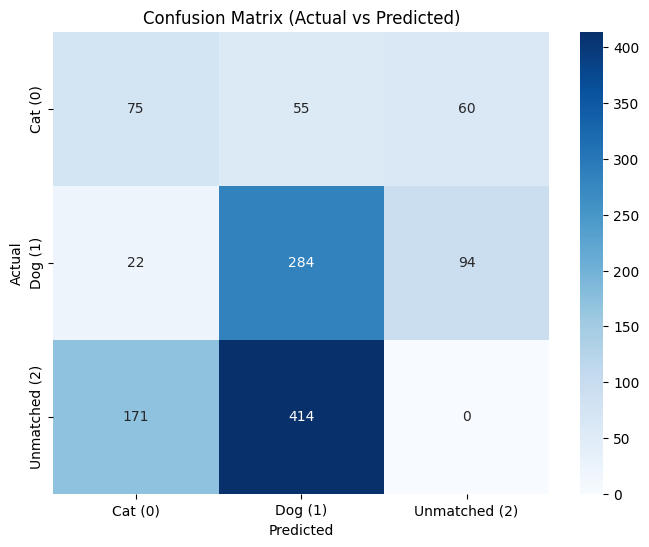

In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_confusion_matrix(model, dataloader, iou_th):
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for valid_batch, valid_bbox_gold, valid_labels, _ in dataloader:
            valid_batch = valid_batch.to(device)
            valid_labels = torch.squeeze(valid_labels, 1).to(device)
            valid_bbox_gold = valid_bbox_gold.to(device).view(-1, 4)

            valid_bbox_pred, valid_objectness_score, valid_class_score = model(valid_batch)
            abs_boxes, abs_scores, abs_labels = map50_input(valid_bbox_pred, valid_class_score, valid_objectness_score, objectness_th=0.1)

            for i in range(len(valid_batch)):
                gt_box = valid_bbox_gold[i]  # [4]
                gt_label = valid_labels[i].item()  # 0 or 1
                pred_boxes = abs_boxes[i]  # [M, 4]
                pred_labels = abs_labels[i]  # [M]
                pred_scores = abs_scores[i]  # [M]

                # Compute IoU
                ious = torch.tensor([box_iou(gt_box, pred_box) for pred_box in pred_boxes]) if len(pred_boxes) > 0 else torch.tensor([])

                # Step 1: TP
                if len(ious) > 0:
                    max_iou, max_idx = ious.max(0)
                    if max_iou > iou_th and pred_labels[max_idx] == gt_label:
                        all_true.append(gt_label)
                        all_pred.append(gt_label)
                        continue

                # Step 2: FN or Misclassification
                if len(ious) == 0 or max_iou <= iou_th:
                    all_true.append(gt_label)
                    all_pred.append(2)  # FN: Predicted None
                elif max_iou > iou_th and pred_labels[max_idx] != gt_label:
                    all_true.append(gt_label)
                    all_pred.append(1 - gt_label)  # Misclassification

                # Step 3-4: FP
                for j, (iou, pred_label) in enumerate(zip(ious, pred_labels)):
                    if j != max_idx or max_iou <= iou_th:
                        all_true.append(2)  # No ground truth
                        all_pred.append(pred_label.item())  # FP

    # Compute confusion matrix
    cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

    # Print text version
    print("Confusion Matrix (Rows: Actual, Cols: Predicted):")
    print("          Cat(0)  Dog(1)  Unmatched(2)")
    print(f"Cat(0):   {cm[0]}")
    print(f"Dog(1):   {cm[1]}")
    print(f"Unmatched(2):  {cm[2]}")

    # Visual confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cat (0)', 'Dog (1)', 'Unmatched (2)'],
                yticklabels=['Cat (0)', 'Dog (1)', 'Unmatched (2)'])
    plt.title('Confusion Matrix (Actual vs Predicted)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return cm

# IoU helper function
def box_iou(box1, box2):
    box2 = box2.squeeze(0)
    x1, y1 = torch.max(box1[:2], box2[:2])
    x2, y2 = torch.min(box1[2:], box2[2:])
    inter = torch.clamp(x2 - x1, min=0) * torch.clamp(y2 - y1, min=0)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

# Call in validation
cm = compute_confusion_matrix(model_v0, test_loader, iou_th=0.5)

# Plots

In [ ]:
import matplotlib.pyplot as plt

# Baseline lenet results
with open(f"/content/drive/MyDrive/p4_results_single_run.json", 'r') as file:
  results = json.load(file)


# read accuracy lists
training_loss = results["training_loss_per_epoch"]
training_xy_loss = results["training_xy_lost_per_epoch"]
training_wh_loss = results["training_wh_lost_per_epoch"]
training_obj_loss = results["training_obj_lost_per_epoch"]
training_noobj_loss = results["training_noobj_lost_per_epoch"]
training_class_loss = results["training_class_lost_per_epoch"]
training_map50 = results["training_map50_per_epoch"]

valid_loss = results["validation_loss_per_epoch"]
valid_xy_loss = results["validation_xy_lost_per_epoch"]
valid_wh_loss = results["validation_wh_lost_per_epoch"]
valid_obj_loss = results["validation_obj_lost_per_epoch"]
valid_noobj_loss = results["validation_noobj_lost_per_epoch"]
valid_class_loss = results["validation_class_lost_per_epoch"]
valid_map50 = results["validation_map50_per_epoch"]


def plot_epochs(model1, model2, model3, list1, list2, list3, ylabel="efe"):
  num_epochs = len(list1)
  a = [i for i in range(num_epochs)]
  num_epochs = len(list2)
  b = [i for i in range(num_epochs)]
  num_epochs = len(list3)
  c = [i for i in range(num_epochs)]
  plt.xlabel("Epochs")
  plt.ylabel(ylabel)
  plt.plot(a, list1, c="red", label=model1)
  plt.plot(b, list2, c="blue", label=model2)
  plt.plot(c, list3, c="green", label=model3)
  plt.legend()
  plt.show()

# Training accuracies
#plot_epochs("baseline", "variant1", "variant2", baseline_training_accuracies, variant1_training_accuracies, variant2_training_accuracies, ylabel="Training accuracies per epoch")
# Validation accuracies
#plot_epochs("baseline", "variant1", "variant2", baseline_validation_accuracies, variant1_validation_accuracies, variant2_validation_accuracies, ylabel="validation accuracies per epoch")
# Training loss
#plot_epochs("baseline", "variant1", "variant2", baseline_training_losses, variant1_training_losses, variant2_training_losses, ylabel="training losses per epoch")
# Validation loss
#plot_epochs("baseline", "variant1", "variant2", baseline_validation_losses, variant1_validation_losses, variant2_validation_losses, ylabel="validation losses per epoch")



def plot_epochs_(model1, training_list, validation_list, ylabel="efe", title="efe"):
  num_epochs = len(training_list)
  a = [i for i in range(num_epochs)]
  num_epochs = len(validation_list)
  b = [i for i in range(num_epochs)]
  plt.xlabel("Epochs")
  plt.ylabel(ylabel)
  plt.plot(a, training_list, c="red", label=f"{model1}, training")
  plt.plot(b, validation_list, c="blue", label=f"{model1}, validation")
  plt.legend()
  plt.title(title)
  plt.savefig(f"/content/drive/MyDrive/{ylabel.split(' ')[0]}.png")
  plt.show()


# Loss
plot_epochs_("model", training_loss, valid_loss, ylabel="Loss per epoch", title="Training/validation loss per epoch")
plot_epochs_("model", training_xy_loss, valid_xy_loss, ylabel="XY loss per epoch", title="Training/validation XY loss per epoch")
plot_epochs_("model", training_wh_loss, valid_wh_loss, ylabel="WH loss per epoch", title="Training/validation WH loss per epoch")
plot_epochs_("model", training_obj_loss, valid_obj_loss, ylabel="Objectness loss per epoch", title="Training/validation objectness loss per epoch")
plot_epochs_("model", training_noobj_loss, valid_noobj_loss, ylabel="Noobject loss per epoch", title="Training/validation noobject loss per epoch")
plot_epochs_("model", training_class_loss, valid_class_loss, ylabel="Classification loss per epoch", title="Training/validation classification loss per epoch")
plot_epochs_("model", training_map50, valid_map50, ylabel="mAP@50 score per epoch", title="Training/validation mAP@50 score per epoch")


In [22]:
import torch

def print_label_ratio(dataloader, dataset_name="Dataset"):
    """
    Print the ratio of labels (Cat: 0, Dog: 1) in a DataLoader.

    Args:
        dataloader: PyTorch DataLoader containing the dataset.
        dataset_name: String name for the dataset (e.g., "Training", "Validation").
    """
    label_counts = {0: 0, 1: 0}  # Cat: 0, Dog: 1

    # Iterate through the DataLoader
    for _, _, labels, _ in dataloader:
        labels = torch.squeeze(labels).cpu().numpy()  # Squeeze and move to CPU
        for label in labels:
            label_counts[int(label)] += 1

    # Calculate totals and ratios
    total = label_counts[0] + label_counts[1]
    cat_percent = (label_counts[0] / total) * 100 if total > 0 else 0
    dog_percent = (label_counts[1] / total) * 100 if total > 0 else 0

    # Avoid division by zero for ratio
    if label_counts[0] == 0:
        ratio = "All Dogs (No Cats)"
    elif label_counts[1] == 0:
        ratio = "All Cats (No Dogs)"
    else:
        ratio_cat_to_dog = label_counts[0] / label_counts[1]
        ratio_dog_to_cat = label_counts[1] / label_counts[0]
        ratio = f"{ratio_cat_to_dog:.2f}:1 (Cat:Dog) or 1:{ratio_dog_to_cat:.2f} (Cat:Dog)"

    # Print results
    print(f"{dataset_name} Label Distribution:")
    print(f"  Cat (0): {label_counts[0]} ({cat_percent:.2f}%)")
    print(f"  Dog (1): {label_counts[1]} ({dog_percent:.2f}%)")
    print(f"  Total: {total}")
    print(f"  Ratio: {ratio}\n")

# Example usage
print_label_ratio(train_loader, "Training")
print_label_ratio(valid_loader, "Validation")
print_label_ratio(test_loader, "Test")

Training Label Distribution:
  Cat (0): 798 (32.23%)
  Dog (1): 1678 (67.77%)
  Total: 2476
  Ratio: 0.48:1 (Cat:Dog) or 1:2.10 (Cat:Dog)

Validation Label Distribution:
  Cat (0): 199 (32.15%)
  Dog (1): 420 (67.85%)
  Total: 619
  Ratio: 0.47:1 (Cat:Dog) or 1:2.11 (Cat:Dog)

Test Label Distribution:
  Cat (0): 190 (32.20%)
  Dog (1): 400 (67.80%)
  Total: 590
  Ratio: 0.47:1 (Cat:Dog) or 1:2.11 (Cat:Dog)



In [ ]:

output_path = "/content/drive/MyDrive"

torch.save(model_v0.state_dict(), f"{output_path}/my_model_params.pth")
#with open(f"{output_path}/lenet_baseline_results_single_run.json", "w") as outfile:
  #json.dump(results, outfile)

In [ ]:
# Initialize the model
model_v0 = CNN().to(device)  # Ensure architecture is the same as when saving

# Load the saved parameters
model_v0.load_state_dict(torch.load('/content/drive/MyDrive/my_model_params.pth'))

# Set model to evaluation mode (if using for inference)
model_v0.eval()

CNN(
  (relu): ReLU()
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv5): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): B

In [ ]:
objectness_th_list = [i * 0.1 for i in range(1,10)]
objectness_th_list.append(0.05)
objectness_th_list.append(0.01)

for i, objectness_th in enumerate(objectness_th_list):
  _, _, correct, tot_images, val_loss, precision, recall, avg_precision, xy_loss_val, wh_loss_val, obj_loss_val, noobj_loss_val, class_loss_val, map50_val = validation(model_v0, test_loader, save_model_performance=False, num_classes=2, test_mode=True, objectness_th=objectness_th)

  print(f"Objectness th: {objectness_th}, validation map50 score: {map50_val}")

## Extra: Detection in video

In [ ]:
# Install dependencies (run once in Colab)
!pip install opencv-python torch torchvision

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import libraries
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import numpy as np

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=2).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/p4_parameters_single_run.pth", map_location=device))
model.eval()

# Custom resize and pad function
def resize_and_pad(image, target_size=112):
    h, w = image.shape[:2]
    if w >= h:  # Width is longer
        new_w = target_size
        new_h = int(target_size * h / w)
    else:  # Height is longer
        new_h = target_size
        new_w = int(target_size * w / h)

    # Resize with aspect ratio
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Pad to 112x112
    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    padded = cv2.copyMakeBorder(
        resized, pad_top, pad_bottom, pad_left, pad_right,
        borderType=cv2.BORDER_CONSTANT, value=[0, 0, 0]  # Black padding
    )
    return padded

# Preprocessing transform
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Process a single frame
def process_frame(frame, model, device, conf_threshold=0.5):
    # Convert BGR to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Resize and pad
    resized_padded = resize_and_pad(frame_rgb, target_size=112)  # [112, 112, 3]

    # Preprocess
    input_tensor = transform(resized_padded).unsqueeze(0).to(device)  # [1, 3, 112, 112]

    # Inference
    with torch.no_grad():
        bbox_pred, obj_score, class_score = model(input_tensor)

    # Post-process
    obj_score = obj_score.squeeze(0)  # [7, 7]
    bbox_pred = bbox_pred.squeeze(0)  # [7, 7, 4]
    class_score = class_score.squeeze(0)  # [7, 7, 2]

    max_obj_score, max_idx = obj_score.view(-1).max(0)
    if max_obj_score < conf_threshold:
        return frame

    grid_y, grid_x = divmod(max_idx.item(), 7)
    bbox = bbox_pred[grid_y, grid_x]
    class_probs = class_score[grid_y, grid_x]
    class_id = class_probs.argmax().item()
    class_label = "Dog" if class_id == 1 else "Cat"
    confidence = max_obj_score.item()

    # Convert to original frame coordinates
    h, w = frame.shape[:2]
    orig_h, orig_w = resized_padded.shape[:2]  # 112x112
    cell_size = 112 / 7

    # Adjust for padding
    if w >= h:
        scale = w / 112
        pad_h = (112 - int(112 * h / w)) // 2
        x_center = (grid_x + bbox[0]) * cell_size * scale
        y_center = ((grid_y + bbox[1]) * cell_size - pad_h) * scale
    else:
        scale = h / 112
        pad_w = (112 - int(112 * w / h)) // 2
        x_center = ((grid_x + bbox[0]) * cell_size - pad_w) * scale
        y_center = (grid_y + bbox[1]) * cell_size * scale

    box_w = bbox[2] * w
    box_h = bbox[3] * h

    xmin = int(x_center - box_w / 2)
    ymin = int(y_center - box_h / 2)
    xmax = int(x_center + box_w / 2)
    ymax = int(y_center + box_h / 2)

    # Draw
    cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    label = f"{class_label}: {confidence:.2f}"
    cv2.putText(frame, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return frame

# Process video
def process_video(video_path, output_path, model, device):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        processed_frame = process_frame(frame, model, device, conf_threshold=0.5)
        out.write(processed_frame)

        frame_count += 1
        if frame_count % 10 == 0:
            print(f"Processed {frame_count} frames")

    cap.release()
    out.release()
    print(f"Video saved to {output_path}")

# Upload and run
from google.colab import files
#uploaded = files.upload()
#video_path = list(uploaded.keys())[0]
video_path = "/content/drive/MyDrive/dog_5.mp4"
output_path = "output_video.mp4"
process_video(video_path, output_path, model, device)
files.download(output_path)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Extra: Resnet finetuning

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class CNN_resnet(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN_resnet, self).__init__()
        # Load pretrained ResNet-18 with ImageNet weights
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Extract the backbone (all layers except the FC layer)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # Up to last conv layer (512x7x7)

        # Define custom FC layers to match your YOLOv1 output
        self.dropout = nn.Dropout(0.2)  # Reduced from 0.4 as before
        self.fc1 = nn.Linear(512 * 7 * 7, 512)  # ResNet-18 output: 512 channels
        self.leaky_relu = nn.ReLU()  # YOLOv1 style
        self.fc2 = nn.Linear(512, 343)         # 7x7x7 = 343 for 7x7 grid, B=1, C=2

        # Initialize only FC layers
        nn.init.kaiming_uniform_(self.fc1.weight, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.kaiming_uniform_(self.fc2.weight, mode='fan_in', nonlinearity='leaky_relu')
        self.name = "my_yolo_with_resnet18"

    def forward(self, x):
        # Input expected: [batch, 3, 224, 224]
        x = self.backbone(x)  # Output: [batch, 512, 7, 7]
        x = self.dropout(x)

        # Flatten and pass through FC layers
        x = torch.flatten(x, 1)  # [batch, 512 * 7 * 7]
        x = self.leaky_relu(self.fc1(x))  # [batch, 512]
        x = self.fc2(x)  # [batch, 343]

        # Reshape to YOLOv1 format
        x = x.view(-1, 7, 7, 7)  # [batch, 7, 7, 7]

        # Split and apply activations
        bbox_pred = torch.sigmoid(x[..., :4])  # [batch, 7, 7, 4]
        objectness_score = torch.sigmoid(x[..., 4])  # [batch, 7, 7]
        class_score = torch.softmax(x[..., 5:],dim=-1)  # [batch, 7, 7, 2]

        return bbox_pred, objectness_score, class_score

    def who(self):
        return self.name


results = {}

tot_val_loss = 0
tot_training_loss = 0
results["name"] = "My YOLO"
max_avg_precision = 0
min_val_loss = float("inf")


model_v1 = CNN_resnet().to(device)
optimizer = torch.optim.Adam(model_v1.parameters(), lr=0.01)


for param in model_v1.backbone.parameters():
    param.requires_grad = True


# Train
model_v1, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train, \
    xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val = train_model(model_v1, train_loader, valid_loader, num_epochs=num_epochs)


print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

#results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results["training_loss_per_epoch"] = training_loss_list
results["training_xy_lost_per_epoch"] = xy_loss_list_train
results["training_wh_lost_per_epoch"] = wh_loss_list_train
results["training_obj_lost_per_epoch"] = obj_loss_list_train
results["training_noobj_lost_per_epoch"] = noobj_loss_list_train
results["training_class_lost_per_epoch"] = class_loss_list_train
results["training_map50_per_epoch"] = map50_list_train


results["validation_loss_per_epoch"] = validation_loss_list
results["validation_xy_lost_per_epoch"] = xy_loss_list_val
results["validation_wh_lost_per_epoch"] = wh_loss_list_val
results["validation_obj_lost_per_epoch"] = obj_loss_list_val
results["validation_noobj_lost_per_epoch"] = noobj_loss_list_val
results["validation_class_lost_per_epoch"] = class_loss_list_val
results["validation_map50_per_epoch"] = map50_list_val

print(training_loss_list, xy_loss_list_train, wh_loss_list_train, obj_loss_list_train, noobj_loss_list_train, class_loss_list_train, map50_list_train)
print(validation_loss_list, xy_loss_list_val, wh_loss_list_val, obj_loss_list_val, noobj_loss_list_val, class_loss_list_val, map50_list_val)


torch.save(model_v0.state_dict(), f"/content/drive/MyDrive/p4_parameters_single_run_resnet.pth")
with open(f"/content/drive/MyDrive/p4_results_single_run_resnet.json", "w") as outfile:
  json.dump(results, outfile)




In [22]:
model_v1 = CNN_resnet().to(device)
x = torch.randn(4, 3, 224, 224).to(device)  # Dummy batch
bbox_pred, obj_score, class_score = model_v1(x)
print(f"bbox_pred: {bbox_pred[0, 0, 0]}")  # Sample values
print(f"objectness_score: {obj_score[0, 0]}")
print(f"class_score: {class_score[0, 0]}")

bbox_pred: tensor([0.0310, 0.1062, 0.0064, 0.7191], device='cuda:0',
       grad_fn=<SelectBackward0>)
objectness_score: tensor([0.8284, 0.0922, 0.5322, 0.6833, 0.8884, 0.8722, 0.9643],
       device='cuda:0', grad_fn=<SelectBackward0>)
class_score: tensor([[0.8799, 0.0121],
        [0.0096, 0.1068],
        [0.5983, 0.0325],
        [0.1347, 0.8155],
        [0.0920, 0.0354],
        [0.8189, 0.1157],
        [0.0093, 0.9447]], device='cuda:0', grad_fn=<SelectBackward0>)


# Extra - Misclassification visualization

In [ ]:
def get_bbox(bbox_pred, conf_scores):
    batch_size = bbox_pred.shape[0]
    # Flatten the grid (batch, 7*7, 4) and scores (batch, 7*7)
    bbox_pred_flat = bbox_pred.reshape(batch_size, -1, 4)
    conf_scores_flat = conf_scores.reshape(batch_size, -1)
    # Get the indices of the max confidence scores per batch
    max_indices = torch.argmax(conf_scores_flat, dim=1)  # Shape: (batch,)
    # Select the best bounding boxes
    final_bboxes = bbox_pred_flat[torch.arange(batch_size), max_indices]  # Shape: (batch, 4)
    return final_bboxes

In [ ]:
# CHOICE TASK 7
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_misdetections(misdetections, num_samples=15):
    """
    Display misclassified images with ground truth and predicted labels.
    """
    fig, axes = plt.subplots(3, 5, figsize=(12, 8))  # Create a 2x5 grid
    axes = axes.flatten()
    
    for i, (img, true_label, pred_label, bbox, bbox_pred) in enumerate(misdetections[:num_samples]):
        img = img.permute(1, 2, 0).cpu().numpy()  # Convert to NumPy array
        img = np.clip(img, 0, 1)  # Ensure values are in the correct range
        
        # Draw bounding box
        x1, y1, x2, y2 = map(int, bbox)
        bbox_pred *=100
        x3, y3, x4, y4 = map(int, bbox_pred)
        color = (1, 0, 0) if true_label != pred_label else (0, 1, 0)  # Red for misclassifications, green for correct
        
        fig_img = img.copy()
        fig_img = cv2.rectangle(fig_img, (x1, y1), (x2, y2), color, 2)
        fig_img = cv2.rectangle(fig_img, (x3, y3), (x4, y4), (0,0,1), 2)
        
        # Display label
        label_text = f"GT: {true_label}, Pred: {pred_label}"
        axes[i].imshow(fig_img)  # Ensure correct color format
        axes[i].axis("off")
        axes[i].set_title(label_text)
    
    plt.tight_layout()
    plt.show()

def validation_with_misdetections(model, dataloader, num_classes=2):
    model.eval()
    misdetections = []
    
    with torch.no_grad():
        for batch, bbox_gold, labels, _ in dataloader:
            batch = batch.to(device)
            labels = labels.to(device)
            bbox_gold = bbox_gold.to(device).view(batch.size(0), 4)
            
            bbox_pred, conf_score, class_score = model(batch)
            bbox_pred2 = get_bbox(bbox_pred, conf_score)
            # print(bbox_pred2)
            
            predicted_labels = prob_to_class(model, bbox_gold, class_score).to(device)
            
            for i in range(batch.size(0)):
                if predicted_labels[i] != labels[i]:
                    misdetections.append((batch[i], labels[i].item(), predicted_labels[i].item(), bbox_gold[i].cpu().numpy(), bbox_pred2[i].cpu().numpy()))
    
    
    return misdetections
# Get misclassified samples
misclassified_samples = validation_with_misdetections(model_v0, valid_loader, num_classes=2)
visualize_misdetections(misclassified_samples)